# 🚀 Full Pipeline: Data Fetching → Training → Backtesting

Complete end-to-end pipeline using modular utilities:
- **Step 1**: Fetch stock prices, SEC fundamentals, and S&P 500 index data (2012-today)
- **Step 2**: Train XGBoost models (2012-2021 training period)
- **Step 3**: Backtest models (2022-today) with 15% stop-loss

Each step includes a summary cell for results analysis.


## 📦 Step 1: Setup and Dependencies

In [4]:
# ============================================================================
# IMPORTS
# ============================================================================

# Core libraries
import pandas as pd
import numpy as np
import warnings
import os
from datetime import datetime

# ============================================================================
# CONFIGURATION - All constants in one place
# ============================================================================

# Data fetching configuration
DATA_START_DATE = '2012-01-03'
# DATA_END_DATE = datetime.now().strftime('%Y-%m-%d')  # Today
DATA_END_DATE = '2025-11-03'


# Training configuration
TRAIN_SPLIT = 0.6  # 80% train, 20% validation
TRAINING_START_DATE = '2012-01-01'
TRAINING_END_DATE = '2025-11-03'
FEATURE_WINDOWS = [5, 10, 15, 20, 25, 30]
TARGET_WINDOWS = [5, 10, 15, 20, 25, 30]
TARGET_WINDOWS_FAST = [5,10,15]
MODEL_TYPES = ['XGBoost']  # Only XGBoost
MODEL_SUFFIX = '2012_2017'  # Tag for models trained on 2012-2021

# Backtesting configuration
BACKTEST_START_DATE = '2018-01-01'
BACKTEST_END_DATE = '2023-12-31'
MAX_POSITIONS = 20
STOP_LOSS = 0.15  # 15% stop-loss
TRADE_WHEN_POSITIONS_ZERO = True
RESULTS_DIR = 'data/research/backtesting/2012_2021_models_backtest_01_2022_11_2025'

warnings.filterwarnings('ignore')

# Set up paths
import sys
sys.path.append('.')

# Import our utilities
from fetch_data_util import (
    fetch_stock_prices,
    fetch_sec_fundamentals,
    fetch_sp500_index
)

from training_util import train_all_models_optimized
from backtesting_util import run_ultra_optimized_backtesting


# Docker network configuration (if running in Docker)
import os
if os.path.exists('/.dockerenv'):
    os.environ['PYTHONHTTPSVERIFY'] = '0'
    os.environ['CURL_CA_BUNDLE'] = ''
    print("🐳 Docker environment detected - network settings applied")
    
# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# ============================================================================
# PRINT CONFIGURATION
# ============================================================================

print("✅ Dependencies loaded successfully!")
print(f"📅 Current time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()
print("="*70)
print("📋 CONFIGURATION")
print("="*70)
print(f"📥 Data Fetching: {DATA_START_DATE} to {DATA_END_DATE}")
print(f"🧪 Backtesting: {BACKTEST_START_DATE} to {BACKTEST_END_DATE}")
print(f"🤖 Models: {MODEL_TYPES}")
print(f"🛡️  Stop-Loss: {STOP_LOSS*100:.0f}%")
print(f"📊 Max Positions: {MAX_POSITIONS}")
print(f"📈 Feature Windows: {FEATURE_WINDOWS}")
print(f"🎯 Target Windows: {TARGET_WINDOWS}")
print("="*70)


🐳 Docker environment detected - network settings applied
✅ Dependencies loaded successfully!
📅 Current time: 2025-11-09 13:18:02

📋 CONFIGURATION
📥 Data Fetching: 2012-01-03 to 2025-11-03
🧪 Backtesting: 2018-01-01 to 2023-12-31
🤖 Models: ['XGBoost']
🛡️  Stop-Loss: 15%
📊 Max Positions: 20
📈 Feature Windows: [5, 10, 15, 20, 25, 30]
🎯 Target Windows: [5, 10, 15, 20, 25, 30]


## 📥 Step 2: Fetch All Data (2012 - Today)


In [5]:
print("="*70)
print("📥 STEP 1: DATA FETCHING")
print("="*70)
print(f"📅 Date range: {DATA_START_DATE} to {DATA_END_DATE}")
print(f"📊 Fetching: Stock prices, SEC fundamentals, S&P 500 index")
print()

# 1. Fetch stock prices
print("📈 Fetching stock prices...")
print("-"*70)
stock_data, stock_metadata = fetch_stock_prices(
    start_date=DATA_START_DATE,
    end_date=DATA_END_DATE,
    verbose=True
)

if stock_data is not None:
    print(f"\n✅ Stock prices fetched: {len(stock_data):,} records")
    print(f"   📁 Saved to: {stock_metadata['filepath']}")
    print(f"   📋 Latest copy: {stock_metadata['latest_filepath']}")
else:
    print("\n❌ Failed to fetch stock prices")
    raise Exception("Stock price fetching failed")


📥 STEP 1: DATA FETCHING
📅 Date range: 2012-01-03 to 2025-11-03
📊 Fetching: Stock prices, SEC fundamentals, S&P 500 index

📈 Fetching stock prices...
----------------------------------------------------------------------
📂 Found latest data file, checking if it matches...
   📊 Latest file has range: 2012-01-03 to 2025-11-03 (905,852 records)
   📅 Requested range: 2012-01-03 to 2025-11-03
   ✅ Latest file covers requested range!
   📈 Symbols: 284
   ✅ Using cached data (no re-fetch needed)

✅ Stock prices fetched: 905,852 records
   📁 Saved to: data/research/stock_data_latest/sp500_stock_data_latest.pkl
   📋 Latest copy: data/research/stock_data_latest/sp500_stock_data_latest.pkl


In [7]:
# Check SEC fundamentals progress (before fetching)
import os
import pandas as pd
from fetch_data_util.config import SEC_DATA_DIR, LATEST_DIR

print("="*70)
print("📊 SEC Fundamentals Progress Check")
print("="*70)

# Check for latest checkpoint
latest_checkpoint = os.path.join(LATEST_DIR, 'sec_fundamentals_latest_in_progress.pkl')
checkpoint_files = []

# Check latest checkpoint
if os.path.exists(latest_checkpoint):
    try:
        df = pd.read_pickle(latest_checkpoint)
        if 'symbol' in df.columns:
            completed = set(df['symbol'].unique())
            print(f"✅ Found latest checkpoint: {os.path.basename(latest_checkpoint)}")
            print(f"   📊 Completed tickers: {len(completed)}")
            print(f"   📈 Total records: {len(df):,}")
            print(f"   📅 Date range: {df['end'].min()} to {df['end'].max()}")
            checkpoint_files.append(('latest', latest_checkpoint, completed))
    except Exception as e:
        print(f"   ⚠️  Could not load latest checkpoint: {str(e)}")

# Check for dated checkpoint files
if os.path.exists(SEC_DATA_DIR):
    import glob
    pattern = os.path.join(SEC_DATA_DIR, '*_in_progress.pkl')
    dated_checkpoints = glob.glob(pattern)
    if dated_checkpoints:
        # Get most recent
        dated_checkpoints.sort(key=os.path.getmtime, reverse=True)
        latest_dated = dated_checkpoints[0]
        try:
            df = pd.read_pickle(latest_dated)
            if 'symbol' in df.columns:
                completed = set(df['symbol'].unique())
                print(f"\n✅ Found dated checkpoint: {os.path.basename(latest_dated)}")
                print(f"   📊 Completed tickers: {len(completed)}")
                print(f"   📈 Total records: {len(df):,}")
                checkpoint_files.append(('dated', latest_dated, completed))
        except Exception as e:
            print(f"   ⚠️  Could not load dated checkpoint: {str(e)}")

if not checkpoint_files:
    print("⚠️  No checkpoint files found")
    print("   Will start fresh on next run")
else:
    # Get all completed tickers (union of all checkpoints)
    all_completed = set()
    for name, path, completed in checkpoint_files:
        all_completed.update(completed)
    
    print(f"\n📋 Summary:")
    print(f"   ✅ Total completed tickers: {len(all_completed)}")
    if 'stock_data' in globals():
        total_tickers = len(stock_data['symbol'].unique())
        remaining = total_tickers - len(all_completed)
        print(f"   📊 Total tickers: {total_tickers}")
        print(f"   ⏳ Remaining: {remaining}")
        print(f"   📈 Progress: {len(all_completed)/total_tickers*100:.1f}%")
    print(f"\n💡 To continue: Just rerun the next cell - it will automatically skip completed tickers!")

print("="*70)


📊 SEC Fundamentals Progress Check
⚠️  No checkpoint files found
   Will start fresh on next run


In [8]:
# 3. Fetch S&P 500 index data
print("\n" + "="*70)
print("📊 Fetching S&P 500 index data...")
print("-"*70)

sp500_index, sp500_metadata = fetch_sp500_index(
    start_date=DATA_START_DATE,
    end_date=DATA_END_DATE,
    verbose=True
)

if sp500_index is not None:
    print(f"\n✅ S&P 500 index fetched: {len(sp500_index):,} records")
    print(f"   📁 Saved to: {sp500_metadata['filepath']}")
    print(f"   📋 Latest copy: {sp500_metadata['latest_filepath']}")
else:
    print("\n❌ Failed to fetch S&P 500 index data")
    raise Exception("S&P 500 index fetching failed")



📊 Fetching S&P 500 index data...
----------------------------------------------------------------------
📊 Fetching S&P 500 index data from Yahoo Finance...
📅 Date range: 2012-01-03 to 2025-11-03
   📈 Ticker: ^GSPC
    ✅ Successfully fetched 3479 records
    📅 Date range: 2012-01-03 00:00:00 to 2025-10-31 00:00:00
    📈 Price range: $1277.06 - $6890.89

💾 Saving data with versioning...
   ✅ Saved CSV to: sp500_index_2012-2025_download_date_09_11_2025.csv
   ✅ Saved to: sp500_index_2012-2025_download_date_09_11_2025.pkl
   📋 Copied to latest: sp500_index_data_latest.pkl

✅ S&P 500 index data saved successfully!
   📄 Main file: sp500_index_2012-2025_download_date_09_11_2025.pkl
   📋 Latest copy: sp500_index_data_latest.pkl
   📈 Total return: 435.62%

✅ S&P 500 index fetched: 3,479 records
   📁 Saved to: data/research/sp500_index/sp500_index_2012-2025_download_date_09_11_2025.pkl
   📋 Latest copy: data/research/stock_data_latest/sp500_index_data_latest.pkl


In [ ]:
# 2. Fetch SEC fundamentals (requires price data)
print("\n" + "="*70)
print("💰 Fetching SEC fundamentals...")
print("-"*70)

# Get unique tickers from stock data
tickers = stock_data['symbol'].unique().tolist()
print(f"📊 Fetching fundamentals for {len(tickers)} tickers...")

try:
    sec_data, sec_metadata = fetch_sec_fundamentals(
        tickers=tickers,
        price_df=stock_data,
        start_date=DATA_START_DATE,
        end_date=DATA_END_DATE,
        verbose=True,
        resume=True  # Enable resume - continues from checkpoint if interrupted
    )
    
    if sec_data is not None:
        print(f"\n✅ SEC fundamentals fetched: {len(sec_data):,} records")
        print(f"   📁 Saved to: {sec_metadata['filepath']}")
        print(f"   📋 Latest copy: {sec_metadata['latest_filepath']}")
    else:
        print("\n⚠️  SEC fundamentals fetch returned no data")
        print("   Continuing without SEC data...")
        sec_data = None
        sec_metadata = None
except Exception as e:
    print(f"\n⚠️  SEC fundamentals fetch failed: {str(e)}")
    print("   Continuing without SEC data...")
    sec_data = None
    sec_metadata = None


💰 Fetching SEC fundamentals...
----------------------------------------------------------------------
📊 Fetching fundamentals for 284 tickers...
🚀 Fetching SEC quarterly fundamental data...
📈 Adding fundamentals for 284 stocks...

📥 Fetching CIK mappings from SEC...
📥 Fetching SEC ticker-CIK mapping...
✅ Found 10142 ticker-CIK mappings
   ✅ Successfully fetched CIK mappings
   ✅ Found CIKs for 283/284 tickers
   ⚠️  Missing CIK for 1 tickers: ['IMB']
   💡 This is normal - some tickers may not have SEC filings

📂 Found existing in-progress checkpoint: sec_fundamentals_2012-2025_download_date_09_11_2025_in_progress.pkl
   ✅ Found 3 tickers in in-progress file

   🔄 Resume Summary:
      ✅ Already completed: 3 tickers (with CIK mappings)
      📊 Total tickers with CIK: 283
      ⏳ Remaining to fetch: 280

  [1/280] 📊 Fetching ABBV...
      ✅ Completed: 3 | ❌ Failed: 0 | ⏱️  ETA: 0.0 min
      🔍 Fetching fundamentals for CIK: 0001551152
      ✅ ABBV: Retrieved 70 quarterly records
      💾

In [11]:
# Check if 'filed' column exists in SEC fundamentals files
import pandas as pd
import os
import glob
from fetch_data_util.config import LATEST_DIR, SEC_DATA_DIR

print("="*70)
print("CHECKING FOR 'filed' COLUMN IN SEC FUNDAMENTALS FILES")
print("="*70)

# Check latest pickle file
latest_pkl = os.path.join(LATEST_DIR, 'sec_fundamentals_latest_in_progress.pkl')
print("\n1. LATEST PICKLE FILE (.pkl)")
print("-"*70)
if os.path.exists(latest_pkl):
    print(f"✅ File exists: {latest_pkl}")
    df = pd.read_pickle(latest_pkl)
    print(f"   📊 Shape: {df.shape}")
    print(f"   📋 Has 'filed' column: {'filed' in df.columns}")
    if 'filed' in df.columns:
        print(f"   ✅ 'filed' column EXISTS")
        print(f"   📅 Sample values:")
        cols = ['ticker', 'end', 'filed'] if 'ticker' in df.columns else ['symbol', 'end', 'filed'] if 'symbol' in df.columns else ['end', 'filed']
        print(df[cols].head(20).to_string())
    else:
        print(f"   ❌ 'filed' column MISSING")
        print(f"   📋 Available columns: {list(df.columns)[:20]}")
else:
    print(f"❌ File does not exist: {latest_pkl}")

# Check latest CSV file
latest_csv = os.path.join(LATEST_DIR, 'sec_fundamentals_latest.csv')
print("\n2. LATEST CSV FILE (.csv)")
print("-"*70)
if os.path.exists(latest_csv):
    print(f"✅ File exists: {latest_csv}")
    df_csv = pd.read_csv(latest_csv, nrows=5)  # Just read header + few rows
    print(f"   📊 Shape (first 5 rows): {df_csv.shape}")
    print(f"   📋 Has 'filed' column: {'filed' in df_csv.columns}")
    if 'filed' in df_csv.columns:
        print(f"   ✅ 'filed' column EXISTS in CSV")
        print(f"   📅 Sample values:")
        cols = ['ticker', 'end', 'filed'] if 'ticker' in df_csv.columns else ['symbol', 'end', 'filed'] if 'symbol' in df_csv.columns else ['end', 'filed']
        if all(c in df_csv.columns for c in cols):
            print(df_csv[cols].head(3).to_string())
    else:
        print(f"   ❌ 'filed' column MISSING in CSV")
        print(f"   📋 Available columns: {list(df_csv.columns)[:20]}")
else:
    print(f"❌ File does not exist: {latest_csv}")

# Check versioned files
print("\n3. VERSIONED FILES")
print("-"*70)
pattern_pkl = os.path.join(SEC_DATA_DIR, 'sec_fundamentals_*.pkl')
pattern_csv = os.path.join(SEC_DATA_DIR, 'sec_fundamentals_*.csv')

pkl_files = [f for f in glob.glob(pattern_pkl) if '_in_progress' not in f and '_v' not in os.path.basename(f)]
csv_files = [f for f in glob.glob(pattern_csv) if '_in_progress' not in f and '_v' not in os.path.basename(f)]

if pkl_files:
    latest_pkl_v = max(pkl_files, key=os.path.getmtime)
    print(f"📄 Latest versioned PKL: {os.path.basename(latest_pkl_v)}")
    df_v = pd.read_pickle(latest_pkl_v)
    print(f"   📋 Has 'filed' column: {'filed' in df_v.columns}")
    if 'filed' in df_v.columns:
        print(f"   ✅ 'filed' column EXISTS")
    else:
        print(f"   ❌ 'filed' column MISSING")
else:
    print("   ⚠️  No versioned PKL files found")

if csv_files:
    latest_csv_v = max(csv_files, key=os.path.getmtime)
    print(f"📄 Latest versioned CSV: {os.path.basename(latest_csv_v)}")
    df_csv_v = pd.read_csv(latest_csv_v, nrows=5)
    print(f"   📋 Has 'filed' column: {'filed' in df_csv_v.columns}")
    if 'filed' in df_csv_v.columns:
        print(f"   ✅ 'filed' column EXISTS")
    else:
        print(f"   ❌ 'filed' column MISSING")
else:
    print("   ⚠️  No versioned CSV files found")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print("The 'filed' column should be in BOTH .pkl and .csv files.")
print("If it's missing, you need to re-fetch the SEC data.")
print("The updated code will preserve the 'filed' column in both formats.")

CHECKING FOR 'filed' COLUMN IN SEC FUNDAMENTALS FILES

1. LATEST PICKLE FILE (.pkl)
----------------------------------------------------------------------
✅ File exists: data/research/stock_data_latest/sec_fundamentals_latest_in_progress.pkl
   📊 Shape: (131, 30)
   📋 Has 'filed' column: True
   ✅ 'filed' column EXISTS
   📅 Sample values:
   ticker        end      filed
0       A 2014-10-31        NaT
1       A 2015-01-31        NaT
2       A 2015-04-30        NaT
3       A 2015-07-31        NaT
4       A 2015-10-31        NaT
5       A 2016-01-31        NaT
6       A 2016-04-30        NaT
7       A 2016-07-31        NaT
8       A 2016-10-31        NaT
9       A 2017-01-31        NaT
10      A 2017-04-30        NaT
11      A 2017-07-31 2018-08-30
12      A 2017-10-31        NaT
13      A 2018-01-31 2019-03-05
14      A 2018-04-30 2019-05-30
15      A 2018-07-31 2019-08-30
16      A 2018-10-31        NaT
17      A 2018-11-01        NaT
18      A 2019-01-31 2020-03-03
19      A 2019-04-3

In [ ]:
# Merge SEC fundamentals with stock prices (point-in-time merge using filed date)
print("="*70)
print("🔄 MERGING SEC FUNDAMENTALS WITH STOCK PRICES")
print("="*70)

from fetch_data_util import merge_fundamentals_with_prices

if sec_data is not None and not sec_data.empty:
    print(f"\n📊 Merging fundamentals with daily stock prices...")
    print(f"   Stock data: {len(stock_data):,} records")
    print(f"   SEC data: {len(sec_data):,} quarterly records")
    
    # Merge using point-in-time logic (filed date)
    merged_data = merge_fundamentals_with_prices(stock_data, sec_data, verbose=True)
    
    # Check if fundamental columns were added
    fundamental_cols = [col for col in merged_data.columns 
                        if any(x in col.lower() for x in ['pe', 'pb', 'ps', 'pcf', 'market_cap', 'revenue', 'equity', 'cir_cap'])]
    
    print(f"\n✅ Merge complete!")
    print(f"   📊 Merged data: {len(merged_data):,} records")
    print(f"   📋 Fundamental columns added: {len(fundamental_cols)}")
    if fundamental_cols:
        print(f"   Sample columns: {fundamental_cols[:10]}")
    
    # Use merged data for training
    training_data = merged_data
else:
    print("\n⚠️  No SEC data available - using stock data only (no fundamental features)")
    training_data = stock_data


## 📊 Step 1 Summary: Data Fetching Results

In [4]:
print("="*70)
print("📊 STEP 1 SUMMARY: DATA FETCHING")
print("="*70)

print(f"\n📈 Stock Prices:")
print(f"   Total records: {len(stock_data):,}")
print(f"   Unique symbols: {stock_data['symbol'].nunique()}")
print(f"   Date range: {stock_data['date'].min()} to {stock_data['date'].max()}")
print(f"   Successful tickers: {len(stock_metadata['successful_tickers'])}")
print(f"   Failed tickers: {len(stock_metadata['failed_tickers'])}")
print(f"   File: {os.path.basename(stock_metadata['filepath'])}")

if sec_data is not None:
    print(f"\n💰 SEC Fundamentals:")
    print(f"   Total records: {len(sec_data):,}")
    if 'symbol' in sec_data.columns:
        print(f"   Unique symbols: {sec_data['symbol'].nunique()}")
    print(f"   File: {os.path.basename(sec_metadata['filepath'])}")
else:
    print(f"\n💰 SEC Fundamentals: Not available")

print(f"\n📊 S&P 500 Index:")
print(f"   Total records: {len(sp500_index):,}")
print(f"   Date range: {sp500_index['date'].min()} to {sp500_index['date'].max()}")
print(f"   Total return: {sp500_metadata['data_info']['total_return_pct']:.2f}%")
print(f"   File: {os.path.basename(sp500_metadata['filepath'])}")

print(f"\n✅ Data fetching complete! Ready for training.")


📊 STEP 1 SUMMARY: DATA FETCHING

📈 Stock Prices:


NameError: name 'stock_data' is not defined

## 🎓 Step 2: Train XGBoost Models (2012-2021)

In [ ]:
print("="*70)
print("🎓 STEP 2: MODEL TRAINING")
print("="*70)
print(f"🤖 Model type: {MODEL_TYPES}")
print(f"📊 Training split: {TRAIN_SPLIT*100:.0f}% train, {(1-TRAIN_SPLIT)*100:.0f}% validation")
print()

# Train only XGBoost models
# Use training_data (merged stock + fundamentals) if available, otherwise stock_data only
train_results = train_all_models_optimized(
    train_start_date=TRAINING_START_DATE,
    train_end_date=TRAINING_END_DATE,
    df=training_data,  # Use merged data (stock + fundamentals) or stock_data if no SEC data
    feature_windows=FEATURE_WINDOWS,
    target_windows=TARGET_WINDOWS_FAST,
    model_types=MODEL_TYPES,
    train_split=TRAIN_SPLIT,
    model_suffix=MODEL_SUFFIX,
    force_recalculate_features=True,  # Use cached features if available
    verbose=True
)

print("\n✅ Training complete!")


🎓 STEP 2: MODEL TRAINING
🤖 Model type: ['XGBoost']
📊 Training split: 60% train, 40% validation


🚀 STARTING OPTIMIZED TRAINING PIPELINE
📊 Total models to train: 18
   Feature windows: [5, 10, 15, 20, 25, 30]
   Target windows: [5, 10, 15]
   Model types: ['XGBoost']
   Model suffix: 2012_2017
   Train split: 60% train, 40% test

💾 Feature cache directory: data/research/features_cache

STEP 1: PRE-CALCULATING FEATURES (with caching)

🔧 PRE-CALCULATING FEATURES FOR ALL WINDOWS
⚠️  TIMING FIX: Features use prices shifted by 1 trading day (T uses data ≤ T-1)
⚠️  Force recalculate enabled - ignoring cache

📊 Window 5 days:
   🔧 Calculating features for 5-day window...

  📊 Creating comprehensive features for 5-day window...
    🔧 Calculating base features...
    📊 Calculating base features for 5-day window...
       ⚠️  Using prices shifted by 1 trading day (T uses data ≤ T-1)
    ✅ Generated 9 base features
    🔧 Calculating momentum features...
    📈 Calculating momentum features for 5-da

    Calculating targets: 100%|██████████| 3480/3480 [00:13<00:00, 267.03it/s]



    ✅ Target distribution for 5-day window:
       🚀 Momentum: 272,271 (30.1%)
       🔄 Reversal: 336,964 (37.3%)
       ⏸️  Do Nothing: 294,057 (32.6%)
   📊 Distribution:
      Class 0 (Momentum): 272,271 samples
      Class 1 (Reversal): 336,964 samples
      Class 2 (Do Nothing): 296,617 samples
   💾 Saving target to cache: data/research/features_cache/target_5d.pkl

🎯 Window 10 days:
   🔧 Calculating target for 10-day window...
    🎯 Calculating multi-class target for 10-day window...
    📅 Processing 3,480 dates...


    Calculating targets: 100%|██████████| 3480/3480 [00:11<00:00, 292.38it/s]



    ✅ Target distribution for 10-day window:
       🚀 Momentum: 297,680 (33.0%)
       🔄 Reversal: 342,384 (38.0%)
       ⏸️  Do Nothing: 260,668 (28.9%)
   📊 Distribution:
      Class 0 (Momentum): 297,680 samples
      Class 1 (Reversal): 342,384 samples
      Class 2 (Do Nothing): 265,788 samples
   💾 Saving target to cache: data/research/features_cache/target_10d.pkl

🎯 Window 15 days:
   🔧 Calculating target for 15-day window...
    🎯 Calculating multi-class target for 15-day window...
    📅 Processing 3,480 dates...


    Calculating targets: 100%|██████████| 3480/3480 [00:10<00:00, 318.89it/s]



    ✅ Target distribution for 15-day window:
       🚀 Momentum: 311,530 (34.7%)
       🔄 Reversal: 346,629 (38.6%)
       ⏸️  Do Nothing: 240,013 (26.7%)
   📊 Distribution:
      Class 0 (Momentum): 311,530 samples
      Class 1 (Reversal): 346,629 samples
      Class 2 (Do Nothing): 247,693 samples
   💾 Saving target to cache: data/research/features_cache/target_15d.pkl

✅ TARGETS READY FOR 3 WINDOWS

STEP 3: TRAINING ALL MODEL COMBINATIONS

📊 FEATURE WINDOW: 5 days

  🎯 TARGET WINDOW: 5 days
     📅 Training date range: 2012-01-01 to 2025-11-03
     📊 Using 60% train / 40% validation split
     📅 Sorted data chronologically: 2012-01-03 00:00:00 to 2025-11-03 00:00:00
     📊 Features after creation: 60 columns
     🔧 Excluded non-feature columns: ['symbol', 'date']
     📊 Features after excluding non-feature cols: 57
     📊 Features after selecting numeric: 57
     📊 Training data: 905,852 samples, 57 features
     ⏭️  XGBoost: Already trained (accuracy: 0.380)

  📊 Progress: 1/18 (5.

## 📊 Step 2 Summary: Training Results

In [ ]:
print("="*70)
print("📊 STEP 2 SUMMARY: MODEL TRAINING")
print("="*70)

# Load training log to see results
import json
from training_util.cache_manager import load_training_log

training_log = load_training_log()

if training_log:
    # Filter for models with configured suffix
    # training_log is a dict: {model_key: {info...}}
    # We need to iterate over items to get both key and value
    xgboost_models = []
    for model_key, info in training_log.items():
        # Check if model_key contains any of the model types and the suffix
        if any(model_type in model_key for model_type in MODEL_TYPES) and MODEL_SUFFIX in model_key:
            # Add model_key to the info dict for easier access
            model_info = info.copy()
            model_info['model_key'] = model_key
            xgboost_models.append(model_info)
    
    print(f"\n📊 Total XGBoost models trained: {len(xgboost_models)}")
    
    if xgboost_models:
        # Sort by accuracy (if available)
        if 'accuracy' in xgboost_models[0]:
            xgboost_models.sort(key=lambda x: x.get('accuracy', 0), reverse=True)
        
        print(f"\n🏆 Top 10 Models by Accuracy:")
        print("-"*70)
        print(f"{'Model Key':<50} {'Accuracy':<12} {'F1 Weighted':<12}")
        print("-"*70)
        
        for model in xgboost_models[:10]:
            model_key = model.get('model_key', 'N/A')
            accuracy = model.get('accuracy', 0) * 100 if 'accuracy' in model else 0
            f1_score = model.get('f1_weighted', 0) if 'f1_weighted' in model else 0
            print(f"{model_key:<50} {accuracy:>10.2f}% {f1_score:>11.4f}")
        
        # Summary statistics
        if 'accuracy' in xgboost_models[0]:
            accuracies = [m.get('accuracy', 0) * 100 for m in xgboost_models]
            print(f"\n📈 Accuracy Statistics:")
            print(f"   Mean: {np.mean(accuracies):.2f}%")
            print(f"   Median: {np.median(accuracies):.2f}%")
            print(f"   Min: {np.min(accuracies):.2f}%")
            print(f"   Max: {np.max(accuracies):.2f}%")
    else:
        print("\n⚠️  No XGBoost models found in training log")
else:
    print("\n⚠️  Training log not found or empty")

print(f"\n✅ Training summary complete! Ready for backtesting.")


## 🧪 Step 3: Backtesting (2022-Today) with 15% Stop-Loss

In [ ]:
print("="*70)
print("🧪 STEP 3: BACKTESTING")
print("="*70)
print(f"📅 Test period: {BACKTEST_START_DATE} to {BACKTEST_END_DATE}")
print(f"🛡️  Stop-loss: {STOP_LOSS*100:.0f}%")
print(f"📊 Models: {MODEL_TYPES} models trained on {DATA_START_DATE} to 2021-12-31")
print()

# Run backtesting with stop-loss enabled
backtest_results = run_ultra_optimized_backtesting(
    test_start_date=BACKTEST_START_DATE,
    test_end_date=BACKTEST_END_DATE,
    max_positions=MAX_POSITIONS,
    verbose=True,
    resume=True,  # Skip already-completed models
    trade_when_positions_zero=TRADE_WHEN_POSITIONS_ZERO,
    include_randomforest=False,  # Only configured model types
    include_xgboost=('XGBoost' in MODEL_TYPES),
    model_suffix=MODEL_SUFFIX,
    stop_loss=STOP_LOSS,
    results_dir=RESULTS_DIR
)

print("\n✅ Backtesting complete!")


## 📊 Step 3 Summary: Backtesting Results

In [ ]:
print("="*70)
print("📊 STEP 3 SUMMARY: BACKTESTING RESULTS")
print("="*70)

if backtest_results is not None and len(backtest_results) > 0:
    print(f"\n📊 Total models backtested: {len(backtest_results)}")
    
    # Sort by total return
    backtest_results_sorted = backtest_results.sort_values('total_return', ascending=False)
    
    print(f"\n🏆 Top 10 Performing Models:")
    print("-"*70)
    print(f"{'Model Key':<50} {'Total Return':<15} {'Trades':<10}")
    print("-"*70)
    
    for idx, row in backtest_results_sorted.head(10).iterrows():
        model_key = row.get('model_key', 'N/A')
        total_return = row.get('total_return', 0) * 100
        total_trades = row.get('total_trades', 0)
        print(f"{model_key:<50} {total_return:>13.2f}% {total_trades:>9.0f}")
    
    # Summary statistics
    returns = backtest_results_sorted['total_return'].values * 100
    print(f"\n📈 Return Statistics:")
    print(f"   Mean: {np.mean(returns):.2f}%")
    print(f"   Median: {np.median(returns):.2f}%")
    print(f"   Min: {np.min(returns):.2f}%")
    print(f"   Max: {np.max(returns):.2f}%")
    
    # Count profitable models
    profitable = (returns > 0).sum()
    print(f"\n💰 Profitable Models: {profitable}/{len(returns)} ({profitable/len(returns)*100:.1f}%)")
    
    # Stop-loss statistics
    if 'stop_loss_triggered' in backtest_results_sorted.columns:
        total_stop_losses = backtest_results_sorted['stop_loss_triggered'].sum()
        total_trades_all = backtest_results_sorted['total_trades'].sum()
        if total_trades_all > 0:
            stop_loss_rate = (total_stop_losses / total_trades_all) * 100
            print(f"\n🛡️  Stop-Loss Statistics:")
            print(f"   Total stop-losses triggered: {total_stop_losses:,.0f}")
            print(f"   Stop-loss rate: {stop_loss_rate:.2f}%")
    
    print(f"\n✅ Backtesting summary complete!")
else:
    print("\n⚠️  No backtesting results found")

print(f"\n🎉 Full pipeline complete!")


## 🎉 Pipeline Complete!

### Summary of All Steps:

1. ✅ **Data Fetching**: Downloaded stock prices, SEC fundamentals, and S&P 500 index (2012-today)
2. ✅ **Model Training**: Trained XGBoost models on 2012-2021 data with 70/30 split
3. ✅ **Backtesting**: Tested models on 2022-today period with 15% stop-loss

### Next Steps:
- Review top-performing models from backtesting results
- Analyze detailed trade logs for best models
- Compare portfolio performance vs S&P 500 index
- Fine-tune models or test different stop-loss levels

## 📈 Performance Comparison: Backtesting vs S&P 500

Visualization comparing the best backtesting results with the S&P 500 index performance.


📈 PERFORMANCE COMPARISON: BACKTESTING vs S&P 500

✅ Loaded S&P 500 index data: 3481 records
   Date range: 2012-01-03 00:00:00 to 2025-11-04 00:00:00

✅ Found 36 backtesting results

🏆 Top 5 Models by Total Return:
   f20d_t5d_XGBoost2012_2021                           235.21%
   f20d_t10d_XGBoost2012_2021                          181.99%
   f5d_t10d_XGBoost2012_2021                           158.09%
   f30d_t5d_XGBoost2012_2021                           152.64%
   f30d_t10d_XGBoost2012_2021                          145.22%
   ✅ Loaded portfolio: f20d_t5d_XGBoost2012_2021
   ✅ Loaded portfolio: f20d_t10d_XGBoost2012_2021
   ✅ Loaded portfolio: f5d_t10d_XGBoost2012_2021
   ✅ Loaded portfolio: f30d_t5d_XGBoost2012_2021
   ✅ Loaded portfolio: f30d_t10d_XGBoost2012_2021


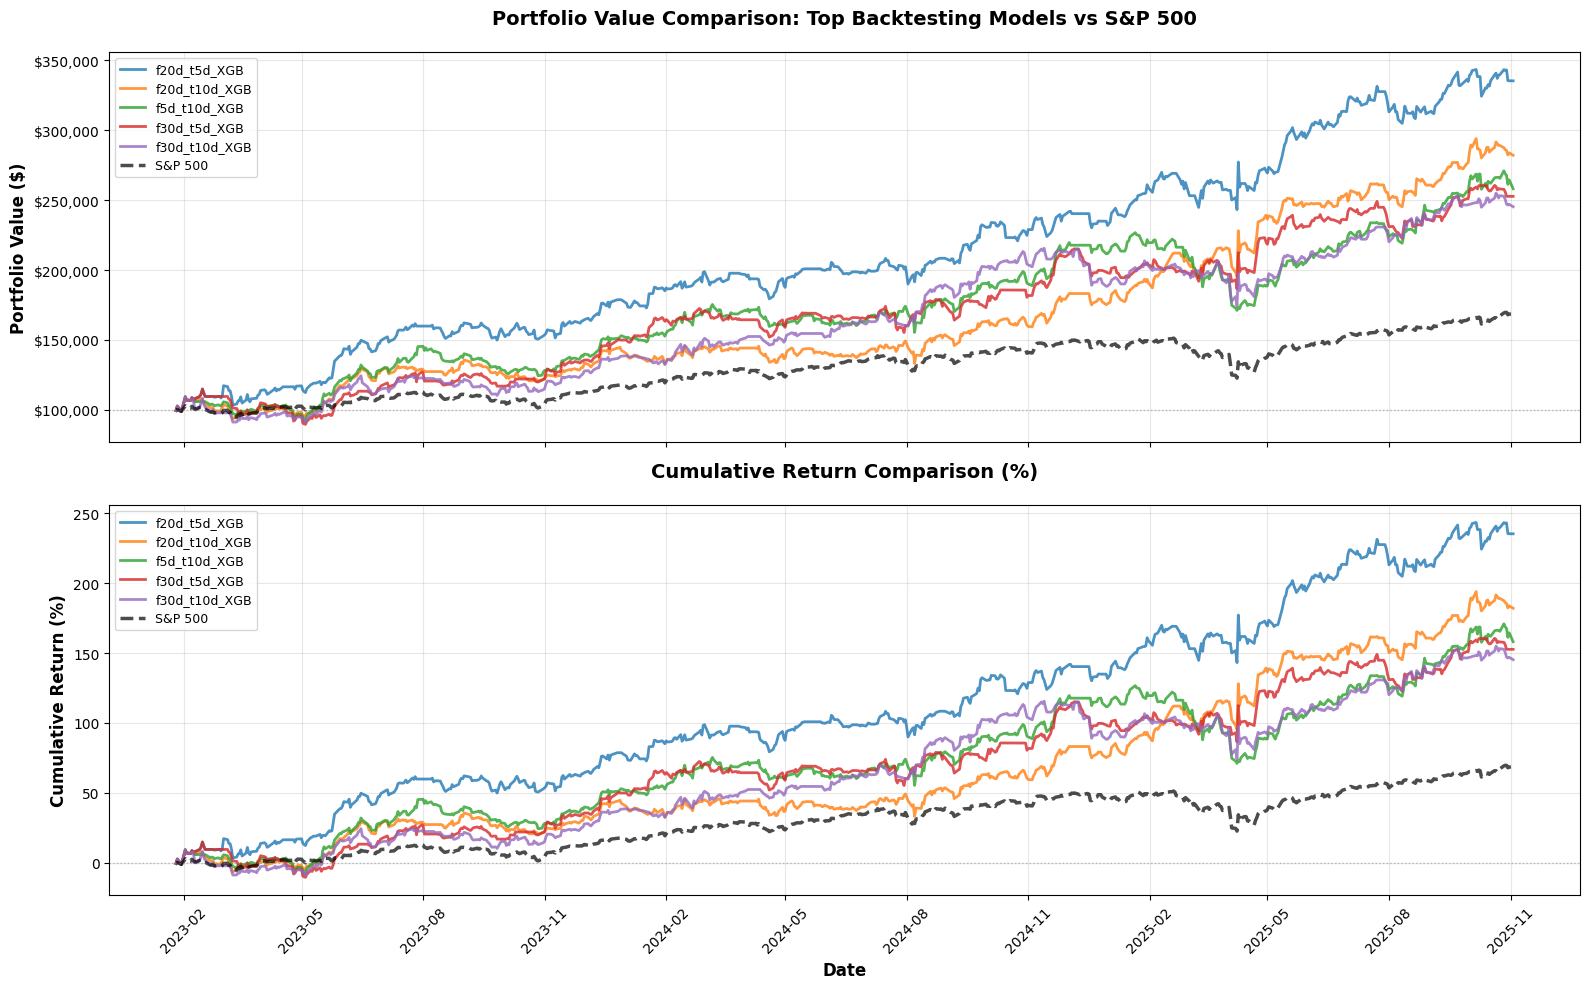


📊 PERFORMANCE SUMMARY
----------------------------------------------------------------------
Model                                              Total Return    Final Value    
----------------------------------------------------------------------
f20d_t5d_XGB                                              235.21% $   335,210.98
f20d_t10d_XGB                                             181.99% $   281,992.03
f5d_t10d_XGB                                              158.09% $   258,088.60
f30d_t5d_XGB                                              152.64% $   252,641.58
f30d_t10d_XGB                                             145.22% $   245,218.30
S&P 500 Index                                              68.75% $   168,749.87
----------------------------------------------------------------------

📈 OUTPERFORMANCE vs S&P 500:
   ✅ f20d_t5d_XGB                                  +166.46%
   ✅ f20d_t10d_XGB                                 +113.24%
   ✅ f5d_t10d_XGB                            

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import os

print("="*70)
print("📈 PERFORMANCE COMPARISON: BACKTESTING vs S&P 500")
print("="*70)

# Load S&P 500 index data
from fetch_data_util.config import LATEST_DIR
sp500_file = os.path.join(LATEST_DIR, 'sp500_index_data_latest.pkl')
if not os.path.exists(sp500_file):
    # Try alternative path
    sp500_file = 'data/research/stock_data_latest/sp500_index_data_latest.pkl'

if os.path.exists(sp500_file):
    sp500_data = pd.read_pickle(sp500_file)
    print(f"\n✅ Loaded S&P 500 index data: {len(sp500_data)} records")
    print(f"   Date range: {sp500_data['date'].min()} to {sp500_data['date'].max()}")
else:
    print(f"\n❌ S&P 500 index data not found. Tried:")
    print(f"   - {os.path.join(LATEST_DIR, 'sp500_index_data_latest.pkl')}")
    print(f"   - data/research/stock_data_latest/sp500_index_data_latest.pkl")
    sp500_data = None

# Load backtesting results summary
if backtest_results is not None and len(backtest_results) > 0:
    print(f"\n✅ Found {len(backtest_results)} backtesting results")
    
    # Find the best performing model(s)
    best_models = backtest_results.nlargest(5, 'total_return')
    print(f"\n🏆 Top 5 Models by Total Return:")
    for idx, row in best_models.iterrows():
        print(f"   {row['model_key']:<50} {row['total_return']*100:>7.2f}%")
    
    # Load portfolio data for top models
    portfolios = {}
    for idx, row in best_models.iterrows():
        model_key = row['model_key']
        # Try to find portfolio file
        portfolio_file = os.path.join(RESULTS_DIR, f"{model_key}_portfolio.csv")
        if not os.path.exists(portfolio_file):
            portfolio_file = os.path.join(RESULTS_DIR, f"{model_key}_portfolio_ultra_optimized.csv")
        
        if os.path.exists(portfolio_file):
            try:
                if portfolio_file.endswith('.pkl'):
                    portfolio_df = pd.read_pickle(portfolio_file)
                else:
                    portfolio_df = pd.read_csv(portfolio_file)
                portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
                portfolios[model_key] = portfolio_df
                print(f"   ✅ Loaded portfolio: {model_key}")
            except Exception as e:
                print(f"   ❌ Error loading {model_key}: {e}")
        else:
            print(f"   ⚠️  Portfolio file not found: {portfolio_file}")
    
    if portfolios and sp500_data is not None:
        # Filter S&P 500 data to match backtesting period
        backtest_start = BACKTEST_START_DATE
        backtest_end = BACKTEST_END_DATE
        
        # Get date range from first portfolio
        first_portfolio = list(portfolios.values())[0]
        actual_start = first_portfolio['date'].min()
        actual_end = first_portfolio['date'].max()
        
        sp500_filtered = sp500_data[
            (sp500_data['date'] >= actual_start) & 
            (sp500_data['date'] <= actual_end)
        ].copy()
        
        # Normalize S&P 500 to start at same value as portfolios (initial capital)
        initial_capital = 100000  # DEFAULT_INITIAL_CAPITAL
        sp500_start_price = sp500_filtered['close'].iloc[0]
        sp500_filtered['normalized_value'] = (sp500_filtered['close'] / sp500_start_price) * initial_capital
        sp500_filtered['cumulative_return_pct'] = ((sp500_filtered['close'] / sp500_start_price) - 1) * 100
        
        # Create the plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
        
        # Plot 1: Portfolio Value Comparison
        colors = plt.cm.tab10(range(len(portfolios)))
        for (model_key, portfolio_df), color in zip(portfolios.items(), colors):
            # Normalize portfolio to start at initial capital
            portfolio_normalized = portfolio_df.copy()
            portfolio_normalized['normalized_value'] = portfolio_df['total_value']
            
            # Short model key for legend
            short_key = model_key.replace(MODEL_SUFFIX, '').replace('XGBoost', 'XGB')[:30]
            ax1.plot(portfolio_normalized['date'], portfolio_normalized['normalized_value'], 
                    label=short_key, linewidth=2, alpha=0.8, color=color)
        
        # Add S&P 500
        ax1.plot(sp500_filtered['date'], sp500_filtered['normalized_value'], 
                label='S&P 500', linewidth=2.5, color='black', linestyle='--', alpha=0.7)
        
        ax1.set_ylabel('Portfolio Value ($)', fontsize=12, fontweight='bold')
        ax1.set_title('Portfolio Value Comparison: Top Backtesting Models vs S&P 500', 
                     fontsize=14, fontweight='bold', pad=20)
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=initial_capital, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        
        # Format y-axis as currency
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        # Plot 2: Cumulative Return Comparison (%)
        for (model_key, portfolio_df), color in zip(portfolios.items(), colors):
            portfolio_df_sorted = portfolio_df.sort_values('date')
            portfolio_df_sorted['cumulative_return_pct'] = ((portfolio_df_sorted['total_value'] / initial_capital) - 1) * 100
            
            short_key = model_key.replace(MODEL_SUFFIX, '').replace('XGBoost', 'XGB')[:30]
            ax2.plot(portfolio_df_sorted['date'], portfolio_df_sorted['cumulative_return_pct'], 
                    label=short_key, linewidth=2, alpha=0.8, color=color)
        
        ax2.plot(sp500_filtered['date'], sp500_filtered['cumulative_return_pct'], 
                label='S&P 500', linewidth=2.5, color='black', linestyle='--', alpha=0.7)
        
        ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cumulative Return (%)', fontsize=12, fontweight='bold')
        ax2.set_title('Cumulative Return Comparison (%)', fontsize=14, fontweight='bold', pad=20)
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)
        ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5, linewidth=1)
        
        # Format x-axis dates
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\n📊 PERFORMANCE SUMMARY")
        print("-"*70)
        print(f"{'Model':<50} {'Total Return':<15} {'Final Value':<15}")
        print("-"*70)
        
        for model_key, portfolio_df in portfolios.items():
            final_value = portfolio_df['total_value'].iloc[-1]
            total_return = ((final_value / initial_capital) - 1) * 100
            short_key = model_key.replace(MODEL_SUFFIX, '').replace('XGBoost', 'XGB')[:48]
            print(f"{short_key:<50} {total_return:>13.2f}% ${final_value:>13,.2f}")
        
        # S&P 500 summary
        sp500_final_value = sp500_filtered['normalized_value'].iloc[-1]
        sp500_total_return = ((sp500_final_value / initial_capital) - 1) * 100
        print(f"{'S&P 500 Index':<50} {sp500_total_return:>13.2f}% ${sp500_final_value:>13,.2f}")
        print("-"*70)
        
        # Calculate outperformance
        print(f"\n📈 OUTPERFORMANCE vs S&P 500:")
        for model_key, portfolio_df in portfolios.items():
            final_value = portfolio_df['total_value'].iloc[-1]
            total_return = ((final_value / initial_capital) - 1) * 100
            outperformance = total_return - sp500_total_return
            short_key = model_key.replace(MODEL_SUFFIX, '').replace('XGBoost', 'XGB')[:48]
            symbol = "✅" if outperformance > 0 else "❌"
            print(f"   {symbol} {short_key:<45} {outperformance:>+7.2f}%")
    else:
        print("\n⚠️  Cannot create visualization - missing portfolio data or S&P 500 data")
else:
    print("\n⚠️  No backtesting results available")
    
print(f"\n✅ Visualization complete!")


NameError: name '__file__' is not defined